# Phase 2: Data Understanding
**CRISP-DM Purpose:** Become familiar with the structure, quality, distributions, and relationships across all 7 source tables before any transformation.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))

from src.config import LABEL_MAP, TARGET, RISK_LEVELS, COOPERATION_MAP, POSITIVE_EMOTIONS
from src.data_io import load_all_csvs
from src.features import build_feature_matrix, add_label

sns.set_theme(style='whitegrid', palette='muted')

tables     = load_all_csvs()
residents  = tables['residents']
health_df  = tables['health']
edu_df     = tables['education']
sessions_df = tables['sessions']
visits_df  = tables['visitations']
plans_df   = tables['plans']
incidents_df = tables['incidents']

# Full feature matrix for cross-table exploration
df_all = build_feature_matrix(residents, health_df, edu_df, sessions_df, visits_df, plans_df, incidents_df)
df_all = add_label(df_all)

# Training subset (known outcomes)
df_train = df_all[df_all[TARGET].notna()].copy()
df_train[TARGET] = df_train[TARGET].astype(int)

print('Tables loaded:')
for name, t in tables.items():
    print(f'  {name:<15} {t.shape[0]:>4} rows × {t.shape[1]} cols')
print(f'\nFeature matrix: {df_all.shape[0]} residents × {df_all.shape[1]} columns')
print(f'Training subset (known outcomes): {len(df_train)} residents')

Tables loaded:
  residents         60 rows × 49 cols
  health           534 rows × 14 cols
  education        534 rows × 10 cols
  sessions        2819 rows × 15 cols
  visitations     1337 rows × 14 cols
  plans            180 rows × 11 cols
  incidents        100 rows × 12 cols

Feature matrix: 60 residents × 97 columns
Training subset (known outcomes): 39 residents


---
## 2.1 Missingness Report

In [2]:
def missingness_report(df, name):
    desc = df.describe(include='all').T
    desc['missing']     = df.isnull().sum()
    desc['missing_pct'] = (df.isnull().mean() * 100).round(1)
    desc['nunique']     = df.nunique()
    desc['dtype']       = df.dtypes
    report = desc[['dtype', 'count', 'missing', 'missing_pct', 'nunique']]
    print(f'\n=== {name} ({df.shape[0]} rows × {df.shape[1]} cols) ===')
    # Only show columns with >0 missing or all of them if small
    has_missing = report[report['missing'] > 0]
    if len(has_missing) > 0:
        print('Columns with missing values:')
        display(has_missing)
    else:
        print('  ✓ No missing values.')

for name, table in tables.items():
    missingness_report(table, name)


=== residents (60 rows × 49 cols) ===
Columns with missing values:


,dtype,count,missing,missing_pct,nunique
pwd_type,str,3,57,95.0,2
special_needs_diagnosis,str,6,54,90.0,3
referring_agency_person,str,36,24,40.0,27
date_colb_registered,datetime64[us],47,13,21.7,45
date_colb_obtained,datetime64[us],36,24,40.0,35
date_case_study_prepared,datetime64[us],49,11,18.3,48
reintegration_type,str,55,5,8.3,5
date_closed,datetime64[us],30,30,50.0,30
notes_restricted,float64,0.0,60,100.0,0



=== health (534 rows × 14 cols) ===
  ✓ No missing values.

=== education (534 rows × 10 cols) ===
  ✓ No missing values.

=== sessions (2819 rows × 15 cols) ===
Columns with missing values:


,dtype,count,missing,missing_pct,nunique
notes_restricted,float64,0.0,2819,100.0,0



=== visitations (1337 rows × 14 cols) ===
Columns with missing values:


,dtype,count,missing,missing_pct,nunique
family_members_present,str,912,425,31.8,100
follow_up_notes,str,788,549,41.1,1



=== plans (180 rows × 11 cols) ===
Columns with missing values:


,dtype,count,missing,missing_pct,nunique
case_conference_date,datetime64[us],132,48,26.7,128



=== incidents (100 rows × 12 cols) ===
Columns with missing values:


,dtype,count,missing,missing_pct,nunique
resolution_date,datetime64[us],71,29,29.0,70


### Data Quality Notes

| Column | Null Behaviour | Classification |
|---|---|---|
| `residents.reintegration_type` | ~5 nulls | Likely not yet assigned for newer/stalled cases — imputed with 'Unknown' in Phase 3 |
| `residents.date_closed` | Null for non-Completed residents | **Leakage risk** — encodes case closure → excluded from features |
| `residents.case_status` | 'Closed' = 19, matching Completed exactly | **Direct leakage** → excluded from features |
| `residents.notes_restricted` | Sparse | Free-text or flag — excluded (PII/privacy) |
| `intervention_plans.target_date` | Some nulls | Not used as a direct feature |
| `incident_reports.*` | 16 residents have zero incidents | Handled by left-join — zeros filled in Phase 3 |

---
## 2.2 Target Distribution

Full reintegration_status breakdown:
  In Progress           21  →  inference only
  Completed             19  →  training (positive)
  On Hold               13  →  training (negative)
  Not Started            7  →  training (negative)

Training set: 39 residents
  Ready (1)     : 19  (48.7%)
  Not Ready (0) : 20  (51.3%)


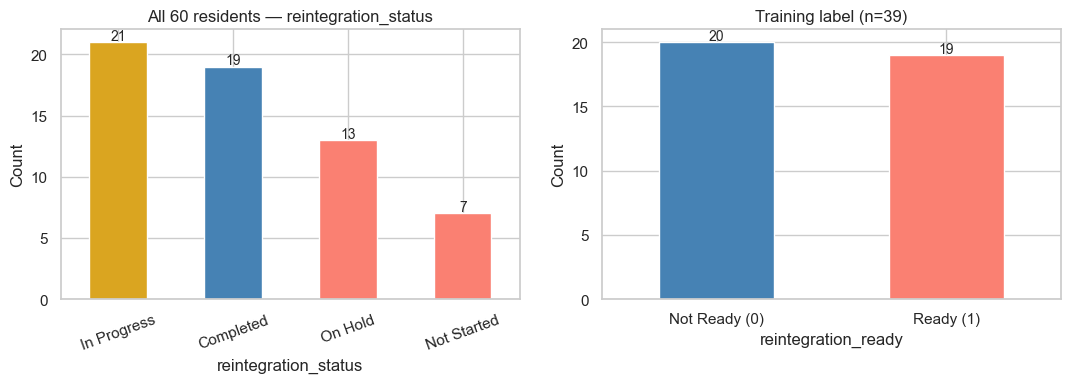

In [3]:
status_counts = residents['reintegration_status'].value_counts()
label_counts  = df_train[TARGET].value_counts()

print('Full reintegration_status breakdown:')
for s, n in status_counts.items():
    role = 'training (positive)' if s == 'Completed' else \
           'training (negative)' if s in ('Not Started', 'On Hold') else \
           'inference only'
    print(f'  {s:<20} {n:>3}  →  {role}')

print(f'\nTraining set: {len(df_train)} residents')
print(f"  Ready (1)     : {label_counts.get(1, 0)}  ({label_counts.get(1, 0)/len(df_train):.1%})")
print(f"  Not Ready (0) : {label_counts.get(0, 0)}  ({label_counts.get(0, 0)/len(df_train):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors_full = [('steelblue' if s == 'Completed' else
                'goldenrod' if s == 'In Progress' else 'salmon')
               for s in status_counts.index]
status_counts.plot(kind='bar', ax=axes[0], color=colors_full, rot=20, edgecolor='white')
axes[0].set_title('All 60 residents — reintegration_status')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 int(bar.get_height()), ha='center', fontsize=10)

label_counts.rename({1: 'Ready (1)', 0: 'Not Ready (0)'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'], rot=0, edgecolor='white')
axes[1].set_title(f'Training label (n={len(df_train)})')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 int(bar.get_height()), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 2.3 Resident Profile Features

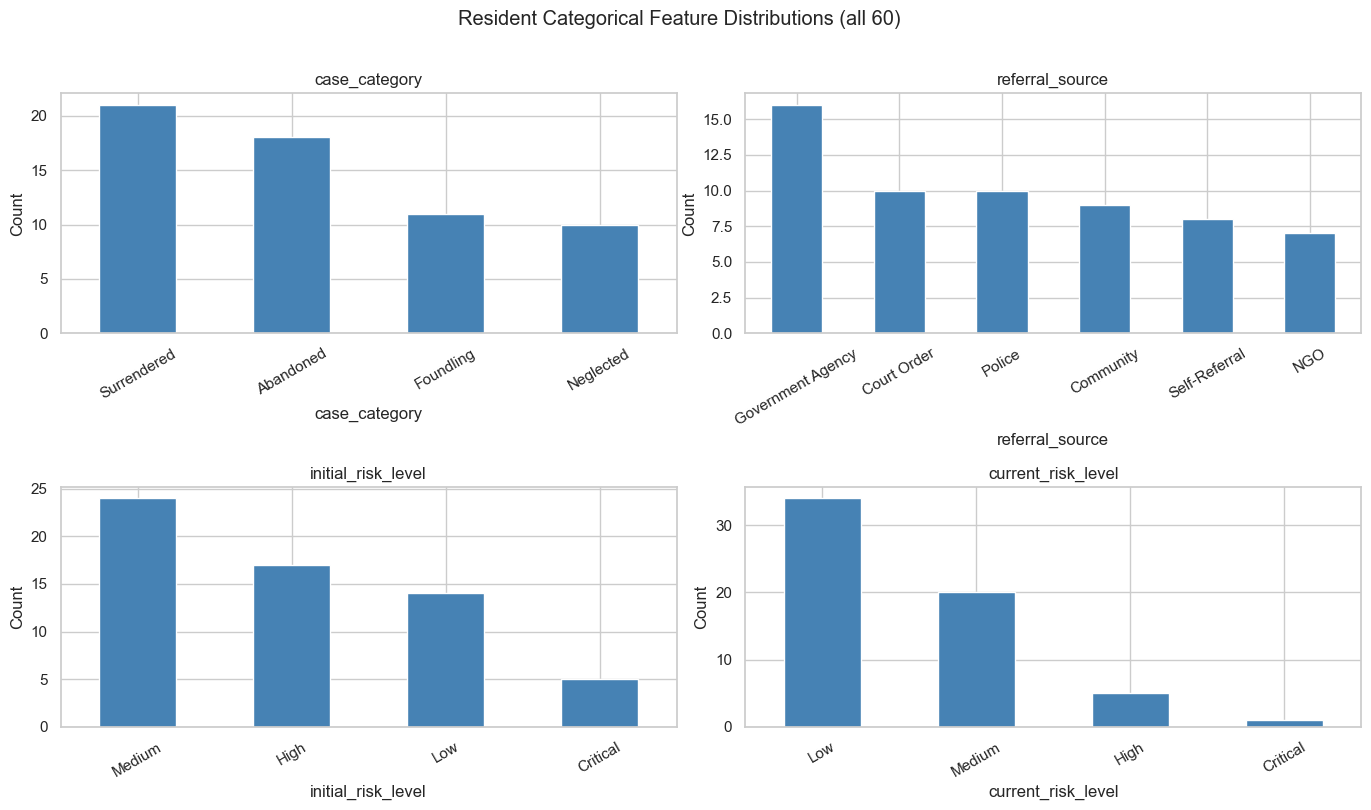

In [4]:
# Categorical breakdown: case_category, referral_source, initial_risk_level
cat_cols = ['case_category', 'referral_source', 'initial_risk_level', 'current_risk_level']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, cat_cols):
    residents[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', rot=30, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Resident Categorical Feature Distributions (all 60)', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# Risk improvement: did current_risk_level improve from initial?
risk_order = list(RISK_LEVELS.keys())  # Low, Medium, High, Critical

r = residents.copy()
r['initial_risk_n'] = r['initial_risk_level'].map(RISK_LEVELS)
r['current_risk_n'] = r['current_risk_level'].map(RISK_LEVELS)
r['risk_improved']  = (r['current_risk_n'] < r['initial_risk_n']).astype(int)

print('Risk improvement (all 60 residents):')
print(r['risk_improved'].value_counts().rename({1: 'Improved', 0: 'Same or worse'}))
print(f'\n{r["risk_improved"].mean():.1%} of residents improved their risk level during care.')

# Risk improvement rate by reintegration status
r_train = r[r['reintegration_status'].isin(['Completed', 'Not Started', 'On Hold'])]
print('\nRisk improvement rate by reintegration_status:')
print(r_train.groupby('reintegration_status')['risk_improved'].mean().round(2))

Risk improvement (all 60 residents):
risk_improved
Same or worse    32
Improved         28
Name: count, dtype: int64

46.7% of residents improved their risk level during care.

Risk improvement rate by reintegration_status:
reintegration_status
Completed      0.58
Not Started    0.43
On Hold        0.46
Name: risk_improved, dtype: float64


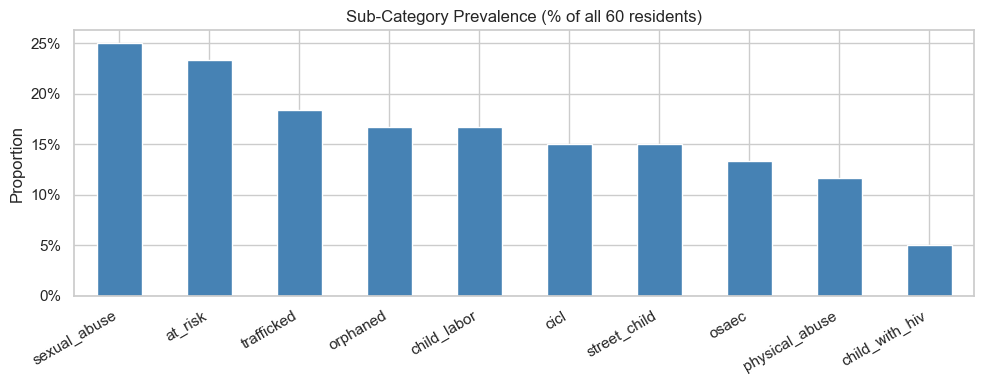

sexual_abuse      0.250000
at_risk           0.233333
trafficked        0.183333
orphaned          0.166667
child_labor       0.166667
cicl              0.150000
street_child      0.150000
osaec             0.133333
physical_abuse    0.116667
child_with_hiv    0.050000


In [6]:
# Sub-category flags (abuse/vulnerability types)
sub_cat_cols = [c for c in residents.columns if c.startswith('sub_cat_')]
sub_cat_rates = residents[sub_cat_cols].astype(bool).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sub_cat_rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Sub-Category Prevalence (% of all 60 residents)')
ax.set_ylabel('Proportion')
ax.set_xticklabels([c.replace('sub_cat_', '') for c in sub_cat_rates.index], rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print(sub_cat_rates.rename(lambda x: x.replace('sub_cat_', '')).to_string())

---
## 2.4 Health & Wellbeing

health_wellbeing_records: 534 records across 60 residents
Records per resident: min=6, max=12, mean=8.9


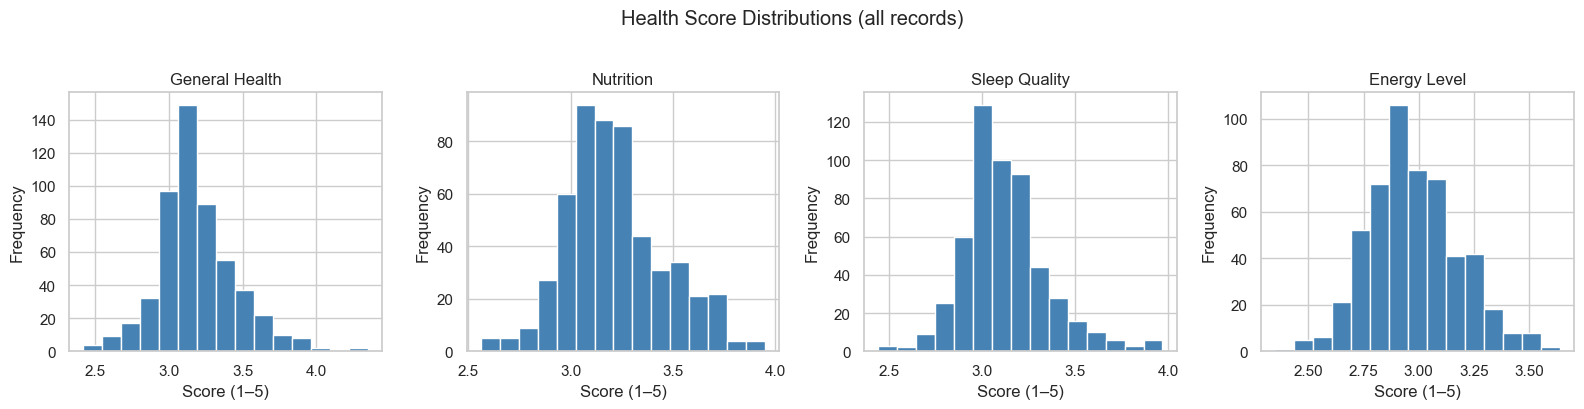


Checkup completion rates:
  medical_checkup_done                58.2%
  dental_checkup_done                 36.0%
  psychological_checkup_done          47.8%


In [7]:
score_cols = ['general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score']

print(f'health_wellbeing_records: {health_df.shape[0]} records across {health_df["resident_id"].nunique()} residents')
print(f'Records per resident: min={health_df.groupby("resident_id").size().min()}, '
      f'max={health_df.groupby("resident_id").size().max()}, '
      f'mean={health_df.groupby("resident_id").size().mean():.1f}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, score_cols):
    health_df[col].dropna().plot(kind='hist', bins=15, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_score', '').replace('_', ' ').title())
    ax.set_xlabel('Score (1–5)')
plt.suptitle('Health Score Distributions (all records)', y=1.02)
plt.tight_layout()
plt.show()

print('\nCheckup completion rates:')
for col in ['medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done']:
    rate = health_df[col].astype(bool).mean()
    print(f'  {col:<35} {rate:.1%}')

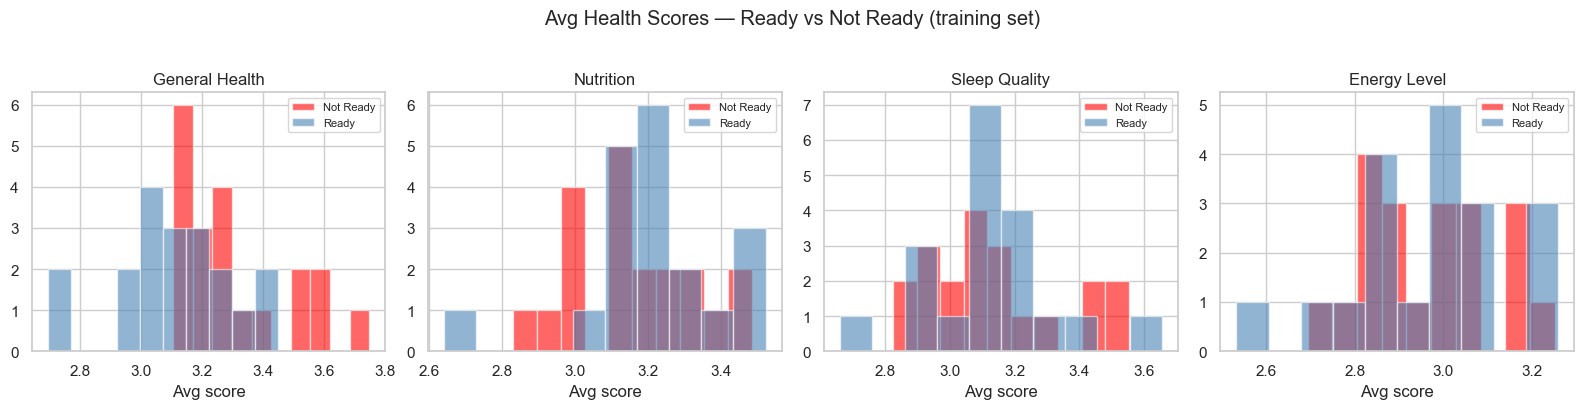

Mean health scores by label (training set):
                     general_health_score  nutrition_score  \
reintegration_ready                                          
Not Ready                           3.304            3.160   
Ready                               3.113            3.208   

                     sleep_quality_score  energy_level_score  
reintegration_ready                                           
Not Ready                          3.132               2.968  
Ready                              3.117               2.973  


In [20]:
# Average health score by reintegration outcome (training set only)
health_by_resident = health_df.groupby('resident_id')[score_cols].mean()
merged = df_train[['resident_id', TARGET]].merge(health_by_resident, on='resident_id', how='left')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, score_cols):
    for label, color, name in [(0, 'red', 'Not Ready'), (1, 'steelblue', 'Ready')]:
        subset = merged[merged[TARGET] == label][col].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(col.replace('_score', '').replace('_', ' ').title())
    ax.set_xlabel('Avg score')
    ax.legend(fontsize=8)
plt.suptitle('Avg Health Scores — Ready vs Not Ready (training set)', y=1.02)
plt.tight_layout()
plt.show()

print('Mean health scores by label (training set):')
print(merged.groupby(TARGET)[score_cols].mean().round(3).rename({0: 'Not Ready', 1: 'Ready'}))

---
## 2.5 Education Records

education_records: 534 records across 60 residents

enrollment_status distribution:
enrollment_status
Enrolled    534
Name: count, dtype: int64

completion_status distribution:
completion_status
InProgress    424
NotStarted     60
Completed      50
Name: count, dtype: int64


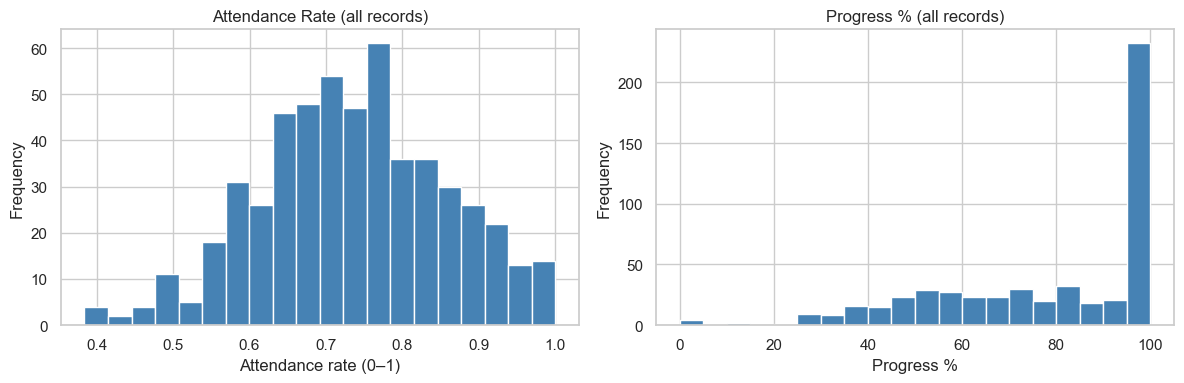


Mean education metrics by label (training set):
                     attendance_rate  progress_percent
reintegration_ready                                   
Not Ready                      0.734            76.737
Ready                          0.740            77.337


In [9]:
print(f'education_records: {edu_df.shape[0]} records across {edu_df["resident_id"].nunique()} residents')
print('\nenrollment_status distribution:')
print(edu_df['enrollment_status'].value_counts())
print('\ncompletion_status distribution:')
print(edu_df['completion_status'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

edu_df['attendance_rate'].plot(kind='hist', bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Attendance Rate (all records)')
axes[0].set_xlabel('Attendance rate (0–1)')

edu_df['progress_percent'].plot(kind='hist', bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Progress % (all records)')
axes[1].set_xlabel('Progress %')

plt.tight_layout()
plt.show()

# Avg attendance and progress by label
edu_by_resident = edu_df.groupby('resident_id')[['attendance_rate', 'progress_percent']].mean()
edu_merged = df_train[['resident_id', TARGET]].merge(edu_by_resident, on='resident_id', how='left')
print('\nMean education metrics by label (training set):')
print(edu_merged.groupby(TARGET)[['attendance_rate', 'progress_percent']].mean().round(3)
      .rename({0: 'Not Ready', 1: 'Ready'}))

---
## 2.6 Process Recordings (Sessions)

In [10]:
print(f'process_recordings: {sessions_df.shape[0]} sessions across {sessions_df["resident_id"].nunique()} residents')
sessions_per_resident = sessions_df.groupby('resident_id').size()
print(f'Sessions per resident: min={sessions_per_resident.min()}, '
      f'max={sessions_per_resident.max()}, mean={sessions_per_resident.mean():.1f}')

print('\nsession_type distribution:')
print(sessions_df['session_type'].value_counts())
print('\nemotional_state_end distribution:')
print(sessions_df['emotional_state_end'].value_counts())

print(f'\nOverall progress_noted rate : {sessions_df["progress_noted"].astype(bool).mean():.1%}')
print(f'Overall concerns_flagged rate: {sessions_df["concerns_flagged"].astype(bool).mean():.1%}')
print(f'Overall referral_made rate   : {sessions_df["referral_made"].astype(bool).mean():.1%}')

process_recordings: 2819 sessions across 60 residents
Sessions per resident: min=11, max=118, mean=47.0

session_type distribution:
session_type
Individual    1805
Group         1014
Name: count, dtype: int64

emotional_state_end distribution:
emotional_state_end
Hopeful      1178
Calm          896
Happy         435
Sad           154
Anxious       137
Withdrawn      19
Name: count, dtype: int64

Overall progress_noted rate : 93.6%
Overall concerns_flagged rate: 24.0%
Overall referral_made rate   : 14.6%


Session metrics by label (training set):
                     n_sessions  pct_progress  pct_concerns  pct_positive_end
reintegration_ready                                                          
Not Ready                43.600         0.943         0.252             0.889
Ready                    52.211         0.938         0.258             0.897


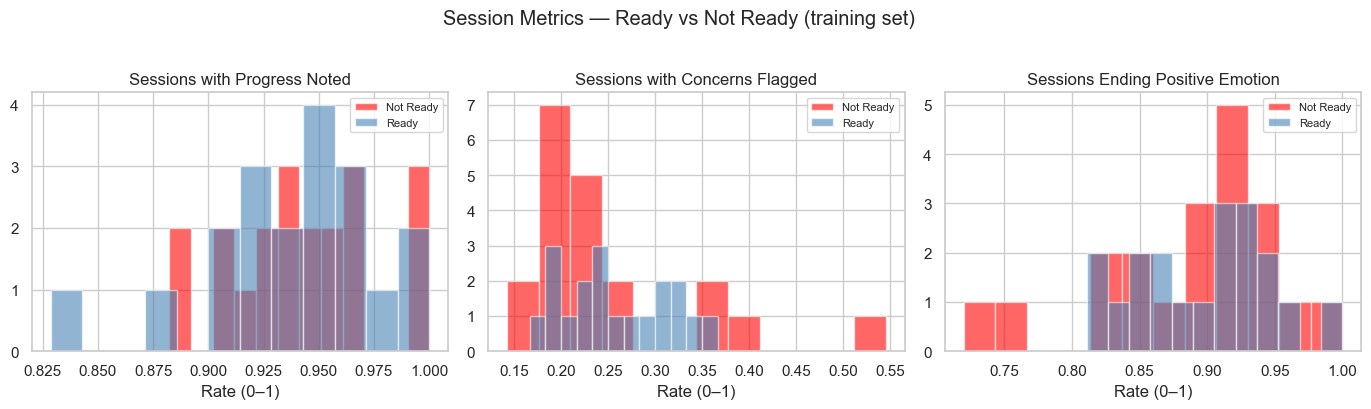

In [21]:
# Key session metrics by label
POSITIVE_EMOTIONS_SET = POSITIVE_EMOTIONS
sessions_df['emotion_positive'] = sessions_df['emotional_state_end'].isin(POSITIVE_EMOTIONS_SET).astype(int)

sess_agg = sessions_df.groupby('resident_id').agg(
    n_sessions          = ('recording_id',        'count'),
    pct_progress        = ('progress_noted',       'mean'),
    pct_concerns        = ('concerns_flagged',     'mean'),
    pct_positive_end    = ('emotion_positive',     'mean'),
).reset_index()

sess_merged = df_train[['resident_id', TARGET]].merge(sess_agg, on='resident_id', how='left')

print('Session metrics by label (training set):')
print(sess_merged.groupby(TARGET)[['n_sessions', 'pct_progress', 'pct_concerns', 'pct_positive_end']]
      .mean().round(3).rename({0: 'Not Ready', 1: 'Ready'}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('pct_progress', 'Sessions with Progress Noted'),
           ('pct_concerns', 'Sessions with Concerns Flagged'),
           ('pct_positive_end', 'Sessions Ending Positive Emotion')]

for ax, (col, title) in zip(axes, metrics):
    for label, color, name in [(0, 'red', 'Not Ready'), (1, 'steelblue', 'Ready')]:
        subset = sess_merged[sess_merged[TARGET] == label][col].dropna()
        ax.hist(subset, bins=12, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Rate (0–1)')
    ax.legend(fontsize=8)
plt.suptitle('Session Metrics — Ready vs Not Ready (training set)', y=1.02)
plt.tight_layout()
plt.show()

---
## 2.7 Home Visitations

In [12]:
print(f'home_visitations: {visits_df.shape[0]} visits across {visits_df["resident_id"].nunique()} residents')
visits_per_resident = visits_df.groupby('resident_id').size()
print(f'Visits per resident: min={visits_per_resident.min()}, '
      f'max={visits_per_resident.max()}, mean={visits_per_resident.mean():.1f}')

print('\nvisit_type distribution:')
print(visits_df['visit_type'].value_counts())
print('\nvisit_outcome distribution:')
print(visits_df['visit_outcome'].value_counts())
print('\nfamily_cooperation_level distribution:')
print(visits_df['family_cooperation_level'].value_counts())

home_visitations: 1337 visits across 58 residents
Visits per resident: min=2, max=64, mean=23.1

visit_type distribution:
visit_type
Routine Follow-Up            542
Reintegration Assessment     316
Initial Assessment           233
Post-Placement Monitoring    182
Emergency                     64
Name: count, dtype: int64

visit_outcome distribution:
visit_outcome
Favorable            551
Needs Improvement    377
Inconclusive         237
Unfavorable          172
Name: count, dtype: int64

family_cooperation_level distribution:
family_cooperation_level
Cooperative           599
Highly Cooperative    378
Neutral               220
Uncooperative         140
Name: count, dtype: int64


Visitation metrics by label (training set):
                     n_visits  n_reintegration_assess  pct_favorable  \
reintegration_ready                                                    
Not Ready              10.833                   1.111          0.432   
Ready                  29.316                   2.579          0.438   

                     avg_cooperation  pct_safety_concerns  
reintegration_ready                                        
Not Ready                      2.048                0.276  
Ready                          1.916                0.262  


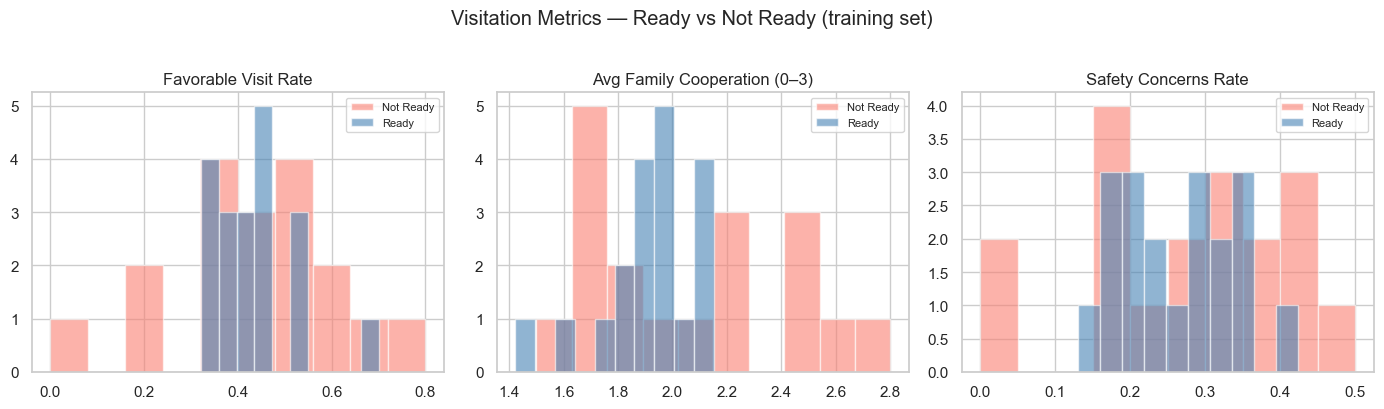

In [13]:
visits_df['visit_favorable']    = (visits_df['visit_outcome'] == 'Favorable').astype(int)
visits_df['cooperation_score']  = visits_df['family_cooperation_level'].map(COOPERATION_MAP)

vis_agg = visits_df.groupby('resident_id').agg(
    n_visits                 = ('visitation_id',     'count'),
    n_reintegration_assess   = ('visit_type',         lambda x: (x == 'Reintegration Assessment').sum()),
    pct_favorable            = ('visit_favorable',    'mean'),
    avg_cooperation          = ('cooperation_score',  'mean'),
    pct_safety_concerns      = ('safety_concerns_noted', 'mean'),
).reset_index()

vis_merged = df_train[['resident_id', TARGET]].merge(vis_agg, on='resident_id', how='left')

print('Visitation metrics by label (training set):')
cols_to_show = ['n_visits', 'n_reintegration_assess', 'pct_favorable', 'avg_cooperation', 'pct_safety_concerns']
print(vis_merged.groupby(TARGET)[cols_to_show].mean().round(3)
      .rename({0: 'Not Ready', 1: 'Ready'}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, title) in zip(axes, [
    ('pct_favorable',       'Favorable Visit Rate'),
    ('avg_cooperation',     'Avg Family Cooperation (0–3)'),
    ('pct_safety_concerns', 'Safety Concerns Rate'),
]):
    for label, color, name in [(0, 'salmon', 'Not Ready'), (1, 'steelblue', 'Ready')]:
        subset = vis_merged[vis_merged[TARGET] == label][col].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle('Visitation Metrics — Ready vs Not Ready (training set)', y=1.02)
plt.tight_layout()
plt.show()

---
## 2.8 Intervention Plans

intervention_plans: 180 plans across 60 residents

plan_category distribution:
plan_category
Safety             60
Education          60
Physical Health    60
Name: count, dtype: int64

status distribution:
status
In Progress    72
Open           39
On Hold        37
Achieved       29
Closed          3
Name: count, dtype: int64

Intervention plan metrics by label (training set):
                     n_plans  n_achieved  achieved_ratio
reintegration_ready                                     
Not Ready                3.0       0.550           0.183
Ready                    3.0       0.211           0.070


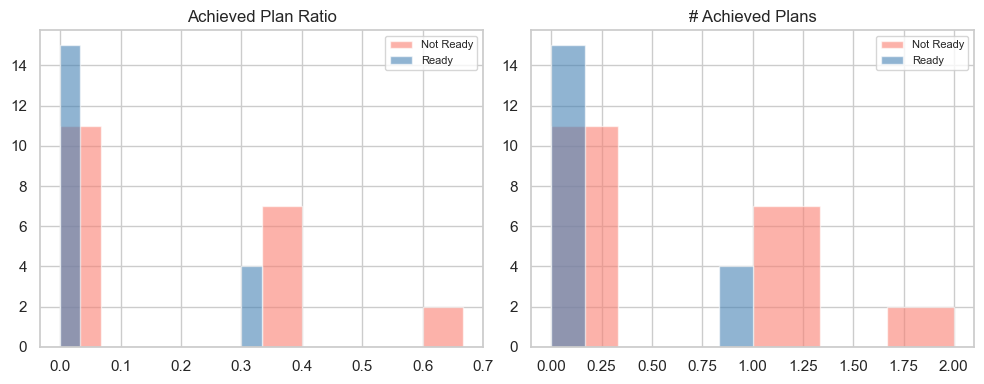

In [14]:
print(f'intervention_plans: {plans_df.shape[0]} plans across {plans_df["resident_id"].nunique()} residents')
print('\nplan_category distribution:')
print(plans_df['plan_category'].value_counts())
print('\nstatus distribution:')
print(plans_df['status'].value_counts())

plan_agg = plans_df.groupby('resident_id').agg(
    n_plans       = ('plan_id', 'count'),
    n_achieved    = ('status',  lambda x: (x == 'Achieved').sum()),
).reset_index()
plan_agg['achieved_ratio'] = plan_agg['n_achieved'] / plan_agg['n_plans'].clip(lower=1)

plan_merged = df_train[['resident_id', TARGET]].merge(plan_agg, on='resident_id', how='left')

print('\nIntervention plan metrics by label (training set):')
print(plan_merged.groupby(TARGET)[['n_plans', 'n_achieved', 'achieved_ratio']].mean().round(3)
      .rename({0: 'Not Ready', 1: 'Ready'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for label, color, name in [(0, 'salmon', 'Not Ready'), (1, 'steelblue', 'Ready')]:
    subset = plan_merged[plan_merged[TARGET] == label]
    axes[0].hist(subset['achieved_ratio'].dropna(), bins=10, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(subset['n_achieved'].dropna(),     bins=6,  alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Achieved Plan Ratio'); axes[0].legend(fontsize=8)
axes[1].set_title('# Achieved Plans');    axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 2.9 Incident Reports

incident_reports: 100 incidents across 44 residents
Residents with zero incidents: 16

incident_type distribution:
incident_type
RunawayAttempt      29
Behavioral          20
Security            16
SelfHarm            14
ConflictWithPeer    11
Medical              6
PropertyDamage       4
Name: count, dtype: int64

severity distribution:
severity
Medium    48
Low       28
High      24
Name: count, dtype: int64

Resolved rate: 71.0%

Incident counts by label (training set):
                     total_incidents  critical
reintegration_ready                           
Not Ready                       1.55      0.55
Ready                           1.63      1.00


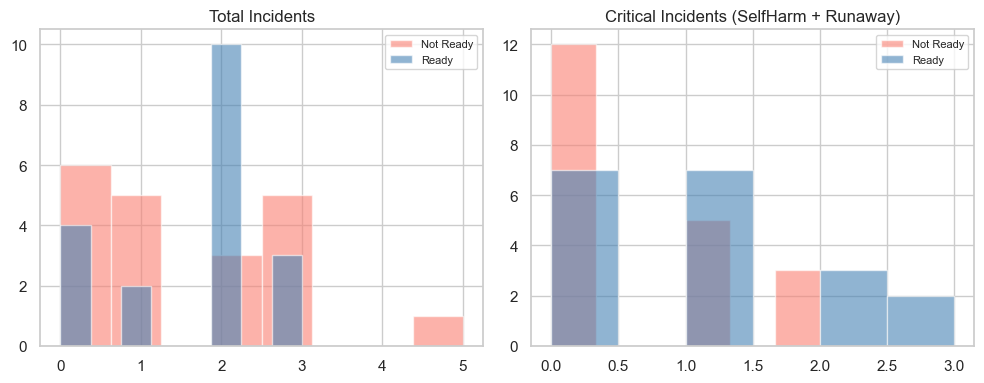

In [15]:
print(f'incident_reports: {incidents_df.shape[0]} incidents across {incidents_df["resident_id"].nunique()} residents')
print(f'Residents with zero incidents: {residents["resident_id"].nunique() - incidents_df["resident_id"].nunique()}')
print('\nincident_type distribution:')
print(incidents_df['incident_type'].value_counts())
print('\nseverity distribution:')
print(incidents_df['severity'].value_counts())
print(f'\nResolved rate: {incidents_df["resolved"].astype(bool).mean():.1%}')

inc_agg = incidents_df.groupby('resident_id').agg(
    total_incidents  = ('incident_id',    'count'),
    high_severity    = ('severity',       lambda x: (x == 'High').sum()),
    selfharm         = ('incident_type',  lambda x: (x == 'SelfHarm').sum()),
    runaway          = ('incident_type',  lambda x: (x == 'RunawayAttempt').sum()),
).reset_index()
inc_agg['critical'] = inc_agg['selfharm'] + inc_agg['runaway']

# Fill zero for residents with no incidents
all_residents = residents[['resident_id', 'reintegration_status']].copy()
inc_full = all_residents.merge(inc_agg, on='resident_id', how='left').fillna(0)

# By label (training set)
inc_train = df_train[['resident_id', TARGET]].merge(inc_full[['resident_id','total_incidents','critical']], on='resident_id', how='left')
print('\nIncident counts by label (training set):')
print(inc_train.groupby(TARGET)[['total_incidents', 'critical']].mean().round(2)
      .rename({0: 'Not Ready', 1: 'Ready'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for label, color, name in [(0, 'salmon', 'Not Ready'), (1, 'steelblue', 'Ready')]:
    subset = inc_train[inc_train[TARGET] == label]
    axes[0].hist(subset['total_incidents'].dropna(), bins=8, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(subset['critical'].dropna(),        bins=6, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Total Incidents'); axes[0].legend(fontsize=8)
axes[1].set_title('Critical Incidents (SelfHarm + Runaway)'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 2.10 Engineered Feature Correlations with Target

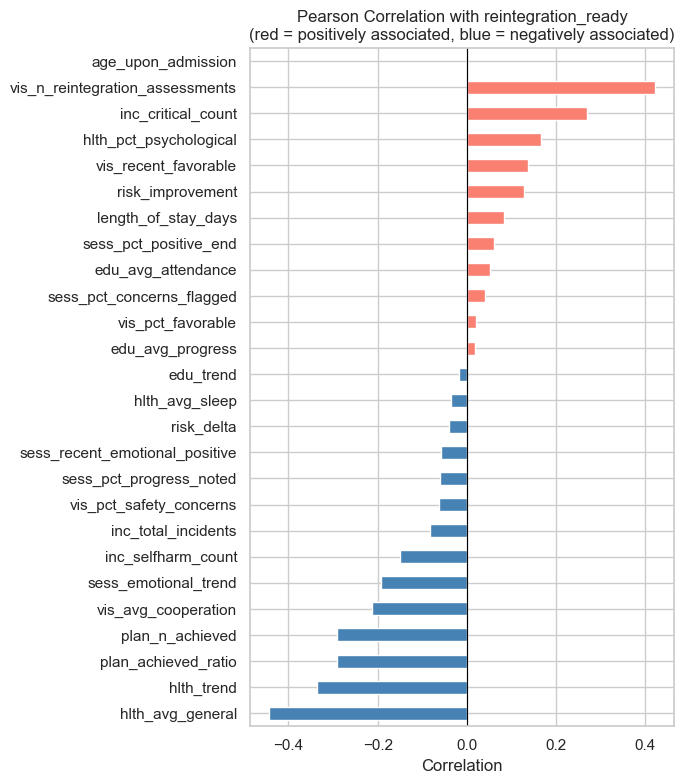


Top 10 features positively correlated with Ready:
                                 reintegration_ready
vis_pct_favorable                              0.020
sess_pct_concerns_flagged                      0.041
edu_avg_attendance                             0.051
sess_pct_positive_end                          0.061
length_of_stay_days                            0.083
risk_improvement                               0.129
vis_recent_favorable                           0.138
hlth_pct_psychological                         0.165
inc_critical_count                             0.270
vis_n_reintegration_assessments                0.421

Top 10 features negatively correlated with Ready:
                         reintegration_ready
hlth_avg_general                      -0.443
hlth_trend                            -0.337
plan_achieved_ratio                   -0.291
plan_n_achieved                       -0.291
vis_avg_cooperation                   -0.213
sess_emotional_trend                  -0.193


In [16]:
# Select key engineered features for correlation heatmap
key_features = [
    'risk_improvement', 'risk_delta', 'length_of_stay_days', 'age_upon_admission',
    'hlth_avg_general', 'hlth_avg_sleep', 'hlth_pct_psychological', 'hlth_trend',
    'edu_avg_attendance', 'edu_avg_progress', 'edu_trend',
    'sess_pct_progress_noted', 'sess_pct_concerns_flagged', 'sess_pct_positive_end',
    'sess_recent_emotional_positive', 'sess_emotional_trend',
    'vis_pct_favorable', 'vis_avg_cooperation', 'vis_n_reintegration_assessments',
    'vis_recent_favorable', 'vis_pct_safety_concerns',
    'plan_achieved_ratio', 'plan_n_achieved',
    'inc_total_incidents', 'inc_critical_count', 'inc_selfharm_count',
    TARGET,
]
available = [c for c in key_features if c in df_train.columns]
corr_df = df_train[available].corr()[[TARGET]].drop(TARGET).sort_values(TARGET)

fig, ax = plt.subplots(figsize=(7, 8))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_df[TARGET]]
corr_df[TARGET].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with reintegration_ready\n(red = positively associated, blue = negatively associated)')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print('\nTop 10 features positively correlated with Ready:')
print(corr_df[corr_df[TARGET] > 0].tail(10).round(3).to_string())
print('\nTop 10 features negatively correlated with Ready:')
print(corr_df[corr_df[TARGET] < 0].head(10).round(3).to_string())

---
## 2.11 Temporal Scope

Residents admitted     : 2023-01-09 → 2025-04-06
Sessions date range    : 2023-01-13 → 2027-02-02
Visitations date range : 2023-02-23 → 2027-01-23
Incidents date range   : 2023-04-08 → 2026-04-09


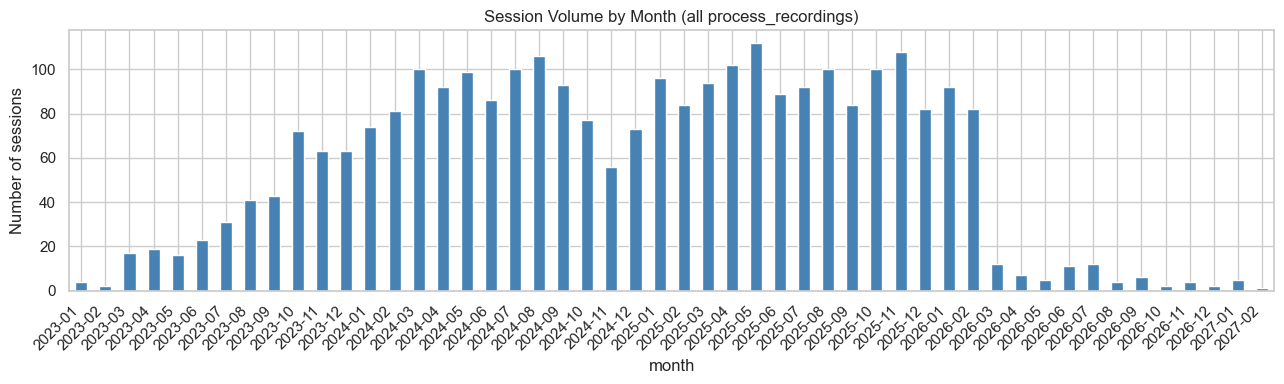

In [17]:
print(f'Residents admitted     : {pd.to_datetime(residents["date_of_admission"]).min().date()} → {pd.to_datetime(residents["date_of_admission"]).max().date()}')
print(f'Sessions date range    : {sessions_df["session_date"].min().date()} → {sessions_df["session_date"].max().date()}')
print(f'Visitations date range : {visits_df["visit_date"].min().date()} → {visits_df["visit_date"].max().date()}')
print(f'Incidents date range   : {incidents_df["incident_date"].min().date()} → {incidents_df["incident_date"].max().date()}')

# Session volume over time
sessions_df['month'] = pd.to_datetime(sessions_df['session_date']).dt.to_period('M')
monthly = sessions_df.groupby('month').size()

fig, ax = plt.subplots(figsize=(13, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Session Volume by Month (all process_recordings)')
ax.set_ylabel('Number of sessions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 2.12 Data Quality Issues — Summary

| Issue | Severity | Resolution (Phase 3) |
|---|---|---|
| `case_status` = 'Closed' ↔ Completed exactly | **Critical leakage** | Exclude from features |
| `date_closed` non-null ↔ Completed closely | **Leakage risk** | Exclude from features |
| `reintegration_type` ~5 nulls | Low | Impute with 'Unknown' category |
| 16 residents have zero incidents | By design | Left-join fills zeros correctly |
| `length_of_stay` stored as string ('X Years Y months') | Inconvenient | Parse to integer days in `features.py` |
| Completed residents have more accumulated history than In Progress | Structural (retrospective framing) | Acknowledged; not fixable — documented in executive summary |

---

## Phase 2 Conclusion

**Data is well-understood and ready for preparation.**

Key findings:
- All 7 tables join cleanly on `resident_id`
- Two columns are direct leakage and must be excluded: `case_status` and `date_closed`
- Most promising features (from correlation analysis): `plan_achieved_ratio`, `vis_avg_cooperation`, `vis_pct_favorable`, `sess_pct_progress_noted`, `risk_improvement`, `inc_critical_count`
- Session emotional positivity and health trends show directional separation between classes
- 16 residents with zero incidents are a real signal (zero incidents may associate with readiness)
- No seasonal patterns in session volume requiring time-series treatment

---
**Proceed to Phase 3: Data Preparation →** `03_data_preparation.ipynb`